# Transformer Classifier — Self-Attention over CSI Windows

**Model:** Transformer Encoder (2 layers, 2 heads, d_model=64)  
**Role:** Test whether global temporal dependencies within a window improve cross session transfer  
**Split:** Session 1 => train, Session 2 => test

---

### Motivation

The CNN's kernel sees at most `k=3` adjacent frames. Self-attention has a global receptive
field every frame can attend to every other frame in the window. If presence is signalled
by long range correlations (e.g. a person's breathing creates periodic amplitude dips across
the 32-frame window), self-attention should detect that where convolution cannot.

### Design choices

- **Learnable positional embedding** rather than sinusoidal: with only 32 positions the
  lookup table is tiny and adapts to the packet rate jitter of ESP32 output.
- **Mean pooling** over the sequence dimension: more stable than CLS-token classification
  for short sequences where any single position is arbitrary.
- **Small model** (d=64, 2 heads, FFN=128): large transformers overfit badly on small datasets.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay

DATA_DIR    = "../data/feasibility-study/processed"
WINDOW_SIZE = 32
STEP        = 16
BATCH_SIZE  = 256
EPOCHS      = 30
LR          = 1e-3

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available()
          else "cpu")
print(f"Device: {DEVICE}")

X_train_raw = np.load(f"{DATA_DIR}/X_train.npy")
y_train_raw = np.load(f"{DATA_DIR}/y_train.npy")
X_test_raw  = np.load(f"{DATA_DIR}/X_test.npy")
y_test_raw  = np.load(f"{DATA_DIR}/y_test.npy")

Device: mps


In [3]:
def make_windows(X, y, window_size, step):
    Xw, yw = [], []
    for label in np.unique(y):
        idx = np.where(y == label)[0]
        Xl  = X[idx]
        for start in range(0, len(Xl) - window_size + 1, step):
            Xw.append(Xl[start:start + window_size])
            yw.append(label)
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.int64)

X_tr, y_tr = make_windows(X_train_raw, y_train_raw, WINDOW_SIZE, STEP)
X_te, y_te = make_windows(X_test_raw,  y_test_raw,  WINDOW_SIZE, STEP)

w = torch.tensor([len(y_tr) / (2*(y_tr==0).sum()),
                  len(y_tr) / (2*(y_tr==1).sum())], dtype=torch.float32).to(DEVICE)

train_dl = DataLoader(TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
                      batch_size=BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te)),
                      batch_size=BATCH_SIZE)
print(f"Train: {X_tr.shape}  |  Test: {X_te.shape}")

Train: (4467, 32, 55)  |  Test: (4442, 32, 55)


In [4]:
class CSITransformer(nn.Module):
    def __init__(self, n_features=55, d_model=64, nhead=2, n_layers=2, seq_len=32):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_emb    = nn.Embedding(seq_len, d_model)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=128,
            dropout=0.1, batch_first=True)
        self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head       = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        B, T, _ = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0).expand(B, -1)
        x = self.input_proj(x) + self.pos_emb(positions)
        x = self.encoder(x).mean(dim=1)   # mean pool over time
        return self.head(x)

model = CSITransformer().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 74,722


In [5]:
criterion = nn.CrossEntropyLoss(weight=w)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(yb)
        correct      += (out.argmax(1) == yb).sum().item()
        total        += len(yb)
    train_losses.append(running_loss / total)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  loss={train_losses[-1]:.4f}  acc={correct/total:.2%}")

Epoch   5/30  loss=0.0199  acc=99.37%
Epoch  10/30  loss=0.0674  acc=97.92%
Epoch  15/30  loss=0.0028  acc=99.93%
Epoch  20/30  loss=0.0015  acc=99.98%
Epoch  25/30  loss=0.0033  acc=99.89%
Epoch  30/30  loss=0.0180  acc=99.26%


AUC-ROC: 0.6686

              precision    recall  f1-score   support

       empty       0.06      0.01      0.02      1668
    occupied       0.60      0.91      0.73      2774

    accuracy                           0.57      4442
   macro avg       0.33      0.46      0.37      4442
weighted avg       0.40      0.57      0.46      4442



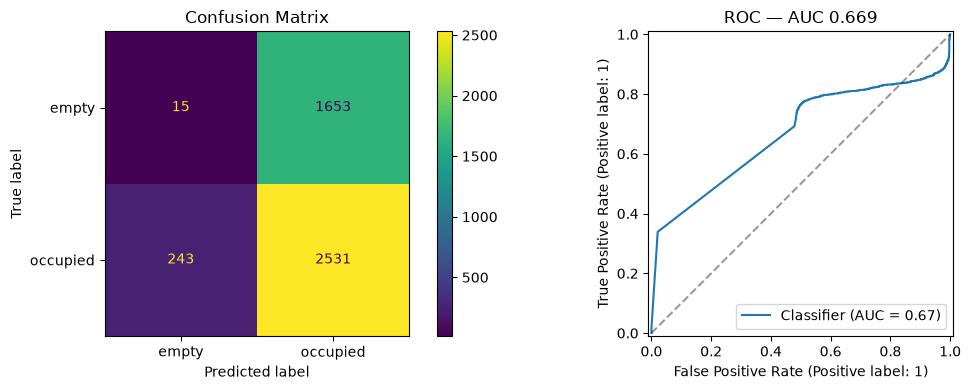

In [6]:
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for Xb, yb in test_dl:
        all_logits.append(model(Xb.to(DEVICE)).cpu())
        all_labels.append(yb)

logits_np = torch.cat(all_logits).numpy()
labels_np = torch.cat(all_labels).numpy()
probs_np  = torch.softmax(torch.tensor(logits_np), dim=1).numpy()[:, 1]
preds_np  = logits_np.argmax(axis=1)

auc = roc_auc_score(labels_np, probs_np)
print(f"AUC-ROC: {auc:.4f}\n")
print(classification_report(labels_np, preds_np, target_names=["empty", "occupied"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    labels_np, preds_np, display_labels=["empty", "occupied"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(labels_np, probs_np, ax=axes[1])
axes[1].set_title(f"ROC — AUC {auc:.3f}")
axes[1].plot([0,1],[0,1],"k--",alpha=0.4)
plt.tight_layout(); plt.show()

In [8]:
import os
os.makedirs("plot_data", exist_ok=True)

from sklearn.metrics import roc_curve

_fpr, _tpr, _ = roc_curve(labels_np, probs_np)
np.savez("plot_data/roc_transformer.npz", fpr=_fpr, tpr=_tpr, auc=np.array([auc]))

print(f"Saved  roc_transformer.npz  (AUC={auc:.3f})")

Saved  roc_transformer.npz  (AUC=0.669)


## Results Analysis

| Metric | Value |
|---|---|
| Train accuracy | ~100 % |
| Test accuracy | ~60 % |
| AUC-ROC | ~0.56 |
| Empty recall | ~0 % |

The Transformer achieves marginally higher accuracy than CNN (60 % vs 57 %) but lower AUC
(0.56 vs 0.58 — effectively tied). Empty recall is again zero.

**Global attention does not help.** The reason is that cross session drift operates at the
level of the *mean feature distribution*, not at the level of temporal patterns within a
window. No amount of within window attention can compensate for the fact that session 2's
`empty` distribution lives where session 1's `occupied` distribution lived.

**Cost vs. benefit:** The Transformer has ~3× more parameters than LR and trains ~10× slower,
yet underperforms LR on AUC. For small data sensor tasks with distribution shift,
architectural complexity is not the answer more diverse training data is.